In [ ]:
# --- Cell 1: Imports ---
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
from sklearn.metrics import confusion_matrix, accuracy_score
RANDOM_STATE = 55

from google.colab import drive
drive.mount('/content/drive')

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]
DATA_PATH   = '/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Dataset/scaled_dataset/'
FIG_PATH    = '/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Outputs/Figures/'


Mounted at /content/drive


In [ ]:
# --- Cell 2: Load arrays ---
X_train = np.load(DATA_PATH + 'X_train_scaled.npy')
X_val   = np.load(DATA_PATH + 'X_val_scaled.npy')
X_test  = np.load(DATA_PATH + 'X_test_scaled.npy')
y_train = np.load(DATA_PATH + 'y_train_bal.npy')
y_val   = np.load(DATA_PATH + 'y_val.npy')
y_test  = np.load(DATA_PATH + 'y_test.npy')

print("Shapes loaded:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape},  y_test:  {y_test.shape}")

Shapes loaded:
  X_train: (45728, 108), y_train: (45728,)
  X_val:   (27495, 108),   y_val:   (27495,)
  X_test:  (27495, 108),  y_test:  (27495,)


In [ ]:
BAND_NAMES = ['cA2', 'cD2', 'cD1']
STAT_NAMES = ['mean', 'std', 'rms', 'peak',
              'crest_factor', 'impulse_factor', 'shape_factor',
              'clearance_factor', 'kurtosis', 'skewness',
              'thd', 'sinad']

FEATURE_NAMES = []
for phase in ['Va', 'Vb', 'Vc']:
    for band in BAND_NAMES:
        for stat in STAT_NAMES:
            FEATURE_NAMES.append(phase + '_' + band + '_' + stat)

assert len(FEATURE_NAMES) == 108, f"Expected 108, got {len(FEATURE_NAMES)}"
assert len(FEATURE_NAMES) == len(set(FEATURE_NAMES)), "Duplicate names found!"

print(f"Feature names verified: {len(FEATURE_NAMES)} unique features")

# Wrap training set in DataFrame for inspection
import pandas as pd
X_train_df = pd.DataFrame(X_train, columns=FEATURE_NAMES)
X_train_df.head()

Feature names verified: 108 unique features


,Va_cA2_mean,Va_cA2_std,Va_cA2_rms,Va_cA2_peak,Va_cA2_crest_factor,Va_cA2_impulse_factor,Va_cA2_shape_factor,Va_cA2_clearance_factor,Va_cA2_kurtosis,Va_cA2_skewness,...,Vc_cD1_rms,Vc_cD1_peak,Vc_cD1_crest_factor,Vc_cD1_impulse_factor,Vc_cD1_shape_factor,Vc_cD1_clearance_factor,Vc_cD1_kurtosis,Vc_cD1_skewness,Vc_cD1_thd,Vc_cD1_sinad
0,-0.266363,0.008631,-0.023455,0.315003,1.136384,0.959718,0.615356,0.679682,1.754640,-0.019960,...,7.175154,7.066842,3.869585,2.746375,1.728941,0.975719,4.699809,1.162413,-0.238016,-4.005654
1,0.580272,0.286677,0.297645,0.281318,-0.317440,-0.450857,-0.552824,-0.244407,-0.633613,-0.722979,...,0.299370,0.183058,-0.703581,-1.172397,-1.162664,-0.897807,-1.220663,-0.176084,1.740590,2.259019
2,0.592484,0.281778,0.294113,0.258537,-0.380900,-0.506888,-0.593892,-0.300238,-0.650264,-0.740738,...,-0.031831,-0.094521,-0.981394,-1.529757,-1.520677,-1.040596,-1.280898,0.444896,-0.543819,1.855866
3,0.573533,0.272828,0.284062,0.275949,-0.281490,-0.431716,-0.557688,-0.232643,-0.530456,-0.753756,...,0.115864,0.061167,-0.230586,-1.485232,-1.646874,-1.070200,-1.439471,0.885894,-0.551464,0.295838
4,0.593417,0.274388,0.287261,0.238160,-0.423020,-0.533801,-0.598250,-0.328195,-0.633158,-0.753741,...,-0.109882,-0.107517,0.119438,-1.159803,-1.353186,-0.945810,-0.719428,0.933813,-0.530961,-1.433271


# ================================================================
#  SVM POLYNOMIAL KERNEL — FULL TRAINING
#  All 108 features, no PCA, degree=5
# ================================================================

In [ ]:
# ================================================================
#  SVM POLYNOMIAL KERNEL — FULL TRAINING
#  All 108 features, no PCA, degree=3
# ================================================================
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import itertools
import numpy as np
import time

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]

# ================================================================
#  CELL 1: TRAINING
# ================================================================
svm_poly = SVC(
    kernel                  = 'poly',
    degree                  = 5,        # cubic polynomial
    C                       = 10,      # margin control
    gamma                   = 'scale',  # auto computed
    coef0                   = 1,        # includes lower degree terms
    decision_function_shape = 'ovo',    # One-vs-One
    random_state            = 42,
    probability             = True
)

print(f"Training SVM Polynomial Kernel (degree=5)...")
print(f"Training samples: {X_train.shape[0]}")
print(f"Features:         {X_train.shape[1]} (all 108, no PCA)")
print(f"Kernel:           Polynomial degree=5")

start = time.time()
svm_poly.fit(X_train, y_train)
end   = time.time()

print(f"\nTraining complete.")
print(f"Training time:   {(end-start):.1f} seconds "
      f"({(end-start)/60:.1f} minutes)")
print(f"Support vectors: {svm_poly.n_support_.sum():,}")
for name, count in zip(CLASS_NAMES, svm_poly.n_support_):
    print(f"  {name}: {count:,}")

Training SVM Polynomial Kernel (degree=5)...
Training samples: 45728
Features:         108 (all 108, no PCA)
Kernel:           Polynomial degree=5

Training complete.
Training time:   326.9 seconds (5.4 minutes)
Support vectors: 5,045
  Non-islanding: 2,570
  Islanding: 2,105
  Line Fault: 370


Classification reports

In [ ]:

y_train_pred_poly = svm_poly.predict(X_train)
y_val_pred_poly   = svm_poly.predict(X_val)
y_test_pred_poly  = svm_poly.predict(X_test)

for name, y_true, y_pred in [
    ("Training",       y_train, y_train_pred_poly),
    ("Validation",     y_val,   y_val_pred_poly),
    ("Test",           y_test,  svm_poly.predict(X_test))
]:
    acc = accuracy_score(y_true, y_pred) * 100
    print(f"\n{'='*55}")
    print(f"  {name}  |  Accuracy: {acc:.2f}%")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred,
                                target_names=CLASS_NAMES,
                                digits=4))


  Training  |  Accuracy: 97.12%
               precision    recall  f1-score   support

Non-islanding     0.9299    0.9983    0.9629     17136
    Islanding     0.9991    0.9248    0.9605     17136
   Line Fault     0.9987    0.9998    0.9993     11456

     accuracy                         0.9712     45728
    macro avg     0.9759    0.9743    0.9742     45728
 weighted avg     0.9731    0.9712    0.9711     45728


  Validation  |  Accuracy: 97.27%
               precision    recall  f1-score   support

Non-islanding     0.9703    0.9887    0.9794     17959
    Islanding     0.9644    0.9053    0.9339      5712
   Line Fault     0.9958    0.9982    0.9970      3824

     accuracy                         0.9727     27495
    macro avg     0.9768    0.9641    0.9701     27495
 weighted avg     0.9726    0.9727    0.9724     27495


  Test  |  Accuracy: 97.84%
               precision    recall  f1-score   support

Non-islanding     0.9737    0.9939    0.9837     17959
    Islanding   

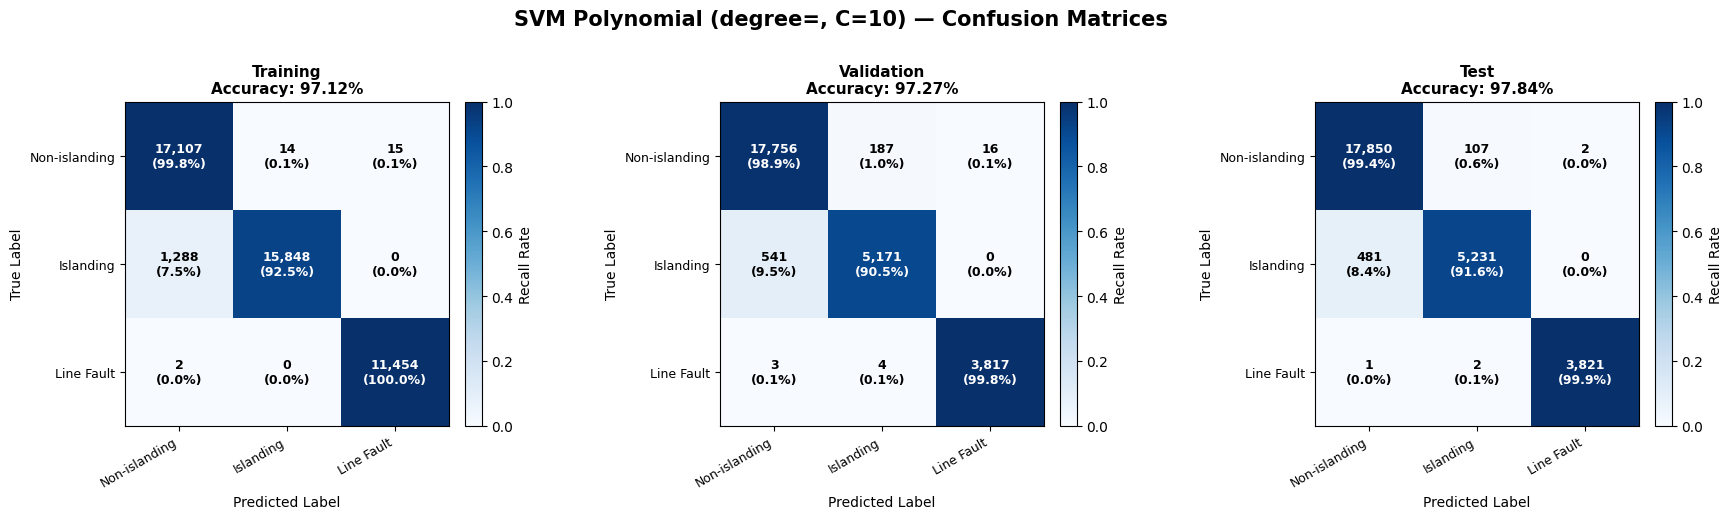

Saved to FIG_PATH


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]

# --- Compute predictions for all three splits ---
splits = [
    ("Training",   X_train, y_train, svm_poly),
    ("Validation", X_val,   y_val,   svm_poly),
    ("Test",       X_test,  y_test,  svm_poly),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SVM Polynomial (degree=, C=10) — Confusion Matrices",
             fontsize=15, fontweight='bold', y=1.02)

for ax, (split_name, X, y, model) in zip(axes, splits):
    preds = model.predict(X)
    cm = confusion_matrix(y, preds)

    # Normalise row-wise (recall perspective)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)

    # Annotate cells with both count and percentage
    for i in range(3):
        for j in range(3):
            count = cm[i, j]
            pct   = cm_norm[i, j] * 100
            color = "white" if cm_norm[i, j] > 0.6 else "black"
            ax.text(j, i, f"{count:,}\n({pct:.1f}%)",
                    ha='center', va='center', fontsize=9,
                    fontweight='bold', color=color)

    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)
    ax.set_title(f"{split_name}", fontsize=12, fontweight='bold')

    # Accuracy annotation below title
    acc = np.trace(cm) / cm.sum() * 100
    ax.set_title(f"{split_name}\nAccuracy: {acc:.2f}%", fontsize=11, fontweight='bold')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Recall Rate")

plt.tight_layout()
plt.savefig(FIG_PATH + "svm_poly_d5_c10_confusion_matrices.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to FIG_PATH")

In [ ]:
import numpy as np

svm_test_preds = svm_poly.predict(X_test)
svm_test_probs = svm_poly.predict_proba(X_test)
np.save('/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Colab_Notebooks/svm_test_preds.npy', svm_test_preds)
np.save('/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Colab_Notebooks/svm_test_probs.npy', svm_test_probs)
print(f"Saved. Shape: {svm_test_preds.shape}")

Saved. Shape: (27495,)
